# Phase 5D: EfficientNet-B3 Baseline
### Automated Classification of Martian Surface Images Captured by NASA's Curiosity Rover Using Machine Learning

---

## 1. Executive Summary & Objective

Across previous phases, multiple model paradigms have been evaluated on the official NASA Curiosity Rover dataset:
- **Phase 4B (KNN-4 Champion)**: Test Accuracy **47.20%**, Test Macro-F1 **0.5407**
- **Phase 5A (ResNet-50 Baseline)**: Test Accuracy **77.78%**, Test Macro-F1 **0.6631**
- **Phase 5B (MRSCAtt)**: Test Accuracy **64.29%**, Test Macro-F1 **0.5851**
- **Phase 5C (ViT-B/16 Baseline)**: Test Accuracy **73.26%**, Test Macro-F1 **0.6536**

**Phase 5D introduces the EfficientNet-B3 Baseline**:
- Employs compound scaling jointly balancing network depth, width, and resolution.
- **Input Resolution**: $300 \times 300$ RGB browse imagery with aspect-ratio-preserving letterbox padding.
- **Pretrained Backbone**: Official torchvision `EfficientNet_B3_Weights.DEFAULT` (ImageNet-1k).
- **Classification Head**: Replaced 1000-class head with `Sequential(Dropout(0.3), Linear(1536, 24))` outputting the 24 active NASA classes.
- **Single-Pass Test Isolation**: The official test set (1,305 images) is evaluated strictly once after checkpoint finalization on Validation Macro-F1.

In [1]:
import os
import sys
from pathlib import Path
import certifi
import json

# Ensure SSL certificates and project path
if 'SSL_CERT_FILE' not in os.environ:
    os.environ['SSL_CERT_FILE'] = certifi.where()

PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import config
from deep_learning import (
    load_synset_mapping,
    load_split_records,
    build_active_class_mappings,
    compute_training_class_weights,
    recompute_metrics_from_predictions,
    get_device
)
from deep_learning.models.efficientnet_b3 import build_efficientnet_b3_baseline

print(f"PyTorch Version : {torch.__version__}")
device = get_device()
print(f"Active Device   : {device}")

PyTorch Version : 2.14.0
Active Device   : mps


## 2. Dataset Verification & Active Class Space

Programmatically verify the official NASA Curiosity Rover splits directly from `Mars rover data/`:

In [2]:
train_records = load_split_records(config.TRAIN_LABELS_PATH)
val_records = load_split_records(config.VAL_LABELS_PATH)
test_records = load_split_records(config.TEST_LABELS_PATH)

print(f"Train samples      : {len(train_records):,} (Expected: 3,746)")
print(f"Validation samples : {len(val_records):,} (Expected: 1,640)")
print(f"Test samples       : {len(test_records):,} (Expected: 1,305)")
print(f"Total images       : {len(train_records) + len(val_records) + len(test_records):,} (Expected: 6,691)")

assert len(train_records) == 3746
assert len(val_records) == 1640
assert len(test_records) == 1305

class_names = load_synset_mapping(config.CLASS_MAPPING_PATH)
orig_to_active, active_to_orig, active_to_name, active_classes = build_active_class_mappings(train_records, class_names)
print(f"\nActive classes     : {len(active_classes)} active classes (NASA IDs 0..21, 23, 24)")
print(f"Zero-sample class  : NASA ID 22 ('{class_names[22]}') correctly excluded from target space.")

Train samples      : 3,746 (Expected: 3,746)
Validation samples : 1,640 (Expected: 1,640)
Test samples       : 1,305 (Expected: 1,305)
Total images       : 6,691 (Expected: 6,691)

Active classes     : 24 active classes (NASA IDs 0..21, 23, 24)
Zero-sample class  : NASA ID 22 ('sun') correctly excluded from target space.


## 3. EfficientNet-B3 Architecture & Parameters

We instantiate the EfficientNet-B3 model and programmatically calculate parameter counts:

In [3]:
model, meta = build_efficientnet_b3_baseline(num_classes=24, pretrained=True, dropout_rate=0.3)
print("EfficientNet-B3 Model Architecture Details:")
for k, v in meta.items():
    print(f"  • {k:<26}: {v}")

# Forward pass check with dummy batch at 300x300
dummy = torch.zeros(2, 3, 300, 300)
with torch.no_grad():
    out = model(dummy)
print(f"\nDummy forward check output shape: {out.shape} (Expected: (2, 24))")
assert out.shape == (2, 24)

EfficientNet-B3 Model Architecture Details:
  • architecture              : EfficientNet-B3
  • pretrained                : True
  • checkpoint                : EfficientNet_B3_Weights.IMAGENET1K_V1
  • input_resolution          : (300, 300)
  • in_features               : 1536
  • num_classes               : 24
  • dropout_rate              : 0.3
  • total_parameters          : 10733120
  • trainable_parameters      : 10733120
  • frozen_parameters         : 0



Dummy forward check output shape: torch.Size([2, 24]) (Expected: (2, 24))


## 4. Training History & Learning Curves

We load and visualize the training and validation history across all epochs from `training_history.csv`:

In [4]:
history_csv = config.PHASE5D_RESULTS_DIR / 'training_history.csv'
if history_csv.is_file():
    history_df = pd.read_csv(history_csv)
    display(history_df.style.format({
        'train_loss': '{:.4f}',
        'train_acc': '{:.2f}%',
        'val_loss': '{:.4f}',
        'val_acc': '{:.2f}%',
        'val_macro_f1': '{:.4f}',
        'val_weighted_f1': '{:.4f}',
        'lr': '{:.2e}'
    }))
else:
    print("Training history not yet generated. Run run_phase5d.py first.")

,train_loss,train_acc,val_loss,val_acc,val_macro_f1,val_macro_precision,val_macro_recall,val_weighted_f1,lr
0,2.3231,48.51%,1.3824,93.48%,0.5843,0.581989,0.608973,0.9341,1.00e-04
1,0.7004,82.06%,0.6716,95.67%,0.6717,0.674536,0.703080,0.9638,9.89e-05
2,0.2601,92.29%,0.4768,95.06%,0.7095,0.709985,0.746899,0.9586,9.57e-05
3,0.1128,96.48%,0.4242,96.10%,0.7242,0.728378,0.751543,0.9661,9.05e-05
4,0.0616,97.65%,0.4717,94.15%,0.7205,0.725644,0.754389,0.9560,8.36e-05
5,0.0559,97.94%,0.2897,97.38%,0.7417,0.744375,0.760572,0.9755,7.52e-05
6,0.0338,98.05%,0.4127,91.52%,0.7188,0.727985,0.751572,0.9400,6.58e-05
7,0.0307,98.40%,0.6823,85.55%,0.6959,0.701081,0.744367,0.8867,5.57e-05
8,0.0267,98.67%,0.3788,94.45%,0.7234,0.732256,0.752100,0.9572,4.53e-05
9,0.0220,98.61%,0.4270,93.84%,0.7227,0.725848,0.758223,0.9538,3.52e-05


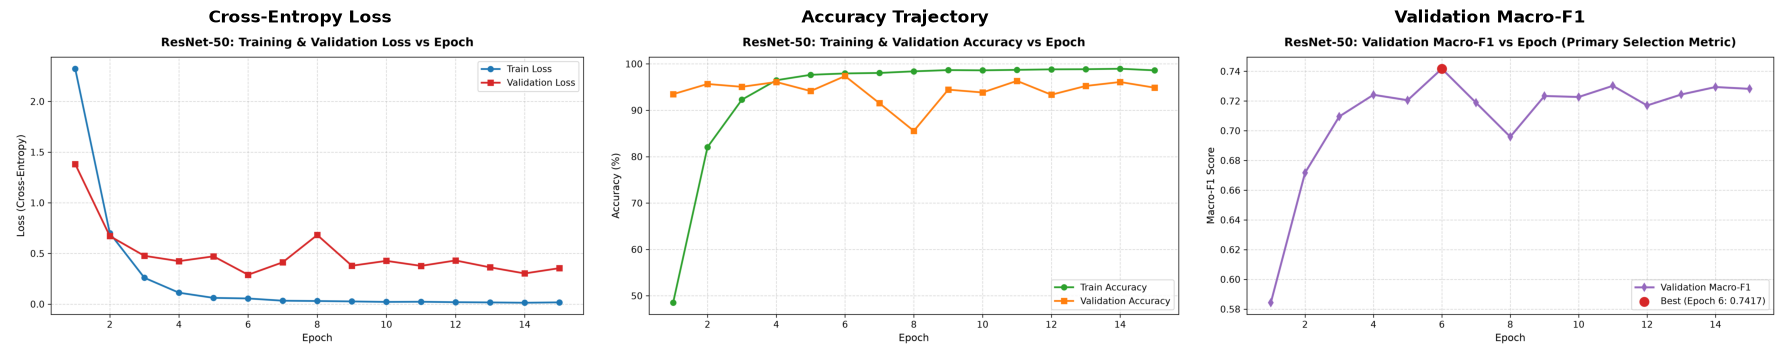

In [5]:
loss_img = config.PHASE5D_PLOTS_DIR / 'training_loss_curve.png'
acc_img = config.PHASE5D_PLOTS_DIR / 'training_accuracy_curve.png'
f1_img = config.PHASE5D_PLOTS_DIR / 'validation_macro_f1_curve.png'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
if loss_img.is_file():
    axes[0].imshow(Image.open(loss_img))
    axes[0].axis('off')
    axes[0].set_title('Cross-Entropy Loss', fontsize=12, fontweight='bold')
if acc_img.is_file():
    axes[1].imshow(Image.open(acc_img))
    axes[1].axis('off')
    axes[1].set_title('Accuracy Trajectory', fontsize=12, fontweight='bold')
if f1_img.is_file():
    axes[2].imshow(Image.open(f1_img))
    axes[2].axis('off')
    axes[2].set_title('Validation Macro-F1', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Best Checkpoint Validation Performance

The best checkpoint was selected strictly based on **Validation Macro-F1**:

In [6]:
metrics_json_path = config.PHASE5D_RESULTS_DIR / 'final_metrics.json'
if metrics_json_path.is_file():
    with open(metrics_json_path, 'r') as f:
        final_metrics = json.load(f)
    val_m = final_metrics['validation_metrics']
    print(f"Best Epoch                 : Epoch {final_metrics['best_epoch']}")
    print(f"Validation Accuracy        : {val_m['accuracy']:.2f}%")
    print(f"Validation Macro-F1        : {val_m['macro_f1']:.4f}")
    print(f"Validation Macro Precision : {val_m['macro_precision']:.4f}")
    print(f"Validation Macro Recall    : {val_m['macro_recall']:.4f}")
    print(f"Validation Weighted-F1     : {val_m['weighted_f1']:.4f}")
    print(f"Validation Loss            : {val_m['loss']:.4f}")
else:
    print("Metrics JSON not found.")

Best Epoch                 : Epoch 6
Validation Accuracy        : 97.38%
Validation Macro-F1        : 0.7417
Validation Macro Precision : 0.7444
Validation Macro Recall    : 0.7606
Validation Weighted-F1     : 0.9755
Validation Loss            : 0.2897


## 6. Official Test Set Evaluation (Single Inference Pass)

Per project rules, the official test set (1,305 images) was evaluated **strictly once** after checkpoint finalization:

In [7]:
if metrics_json_path.is_file():
    test_m = final_metrics['test_metrics']
    print(f"Test Accuracy              : {test_m['accuracy']:.2f}%")
    print(f"Test Macro-F1              : {test_m['macro_f1']:.4f}")
    print(f"Test Macro Precision       : {test_m['macro_precision']:.4f}")
    print(f"Test Macro Recall          : {test_m['macro_recall']:.4f}")
    print(f"Test Weighted-F1           : {test_m['weighted_f1']:.4f}")
    print(f"Test Cross-Entropy Loss    : {test_m['loss']:.4f}")
    print(f"Total Test Inference Time  : {test_m['total_inference_time_s']:.2f} seconds")
    print(f"Per-Sample Latency         : {test_m['ms_per_sample']:.2f} ms/sample")
else:
    print("Metrics JSON not found.")

Test Accuracy              : 80.61%
Test Macro-F1              : 0.7083
Test Macro Precision       : 0.7307
Test Macro Recall          : 0.7487
Test Weighted-F1           : 0.8288
Test Cross-Entropy Loss    : 1.0690
Total Test Inference Time  : 20.34 seconds
Per-Sample Latency         : 15.59 ms/sample


## 7. Per-Class Performance & Classification Report

We inspect the full per-class metrics on the official test set:

In [8]:
test_rep_csv = config.PHASE5D_REPORTS_DIR / 'test_classification_report.csv'
if test_rep_csv.is_file():
    report_df = pd.read_csv(test_rep_csv)
    display(report_df)
else:
    print("Report CSV not found.")

,Active Index,Class Name,Precision,Recall,F1-Score,Support
0,0,apxs,0.9444,1.0000,0.9714,34
1,1,apxs cal target,1.0000,1.0000,1.0000,14
2,2,chemcam cal target,1.0000,1.0000,1.0000,21
3,3,chemin inlet open,1.0000,0.6190,0.7647,84
4,4,drill,0.5556,0.7500,0.6383,20
5,5,drill holes,0.0000,0.0000,0.0000,0
6,6,drt front,0.9512,0.6500,0.7723,60
7,7,drt side,1.0000,0.6000,0.7500,150
8,8,ground,0.9841,0.7323,0.8397,254
9,9,horizon,0.5702,0.9583,0.7150,72


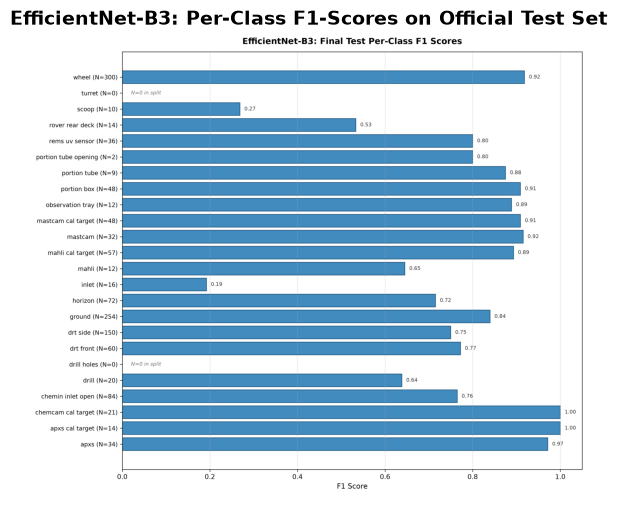

In [9]:
f1_bar_img = config.PHASE5D_PLOTS_DIR / 'per_class_f1_test_barchart.png'
if f1_bar_img.is_file():
    plt.figure(figsize=(12, 6))
    plt.imshow(Image.open(f1_bar_img))
    plt.axis('off')
    plt.title('EfficientNet-B3: Per-Class F1-Scores on Official Test Set', fontsize=14, fontweight='bold')
    plt.show()

## 8. Confusion Matrix Heatmaps

Visualize the raw counts and normalized test confusion matrices:

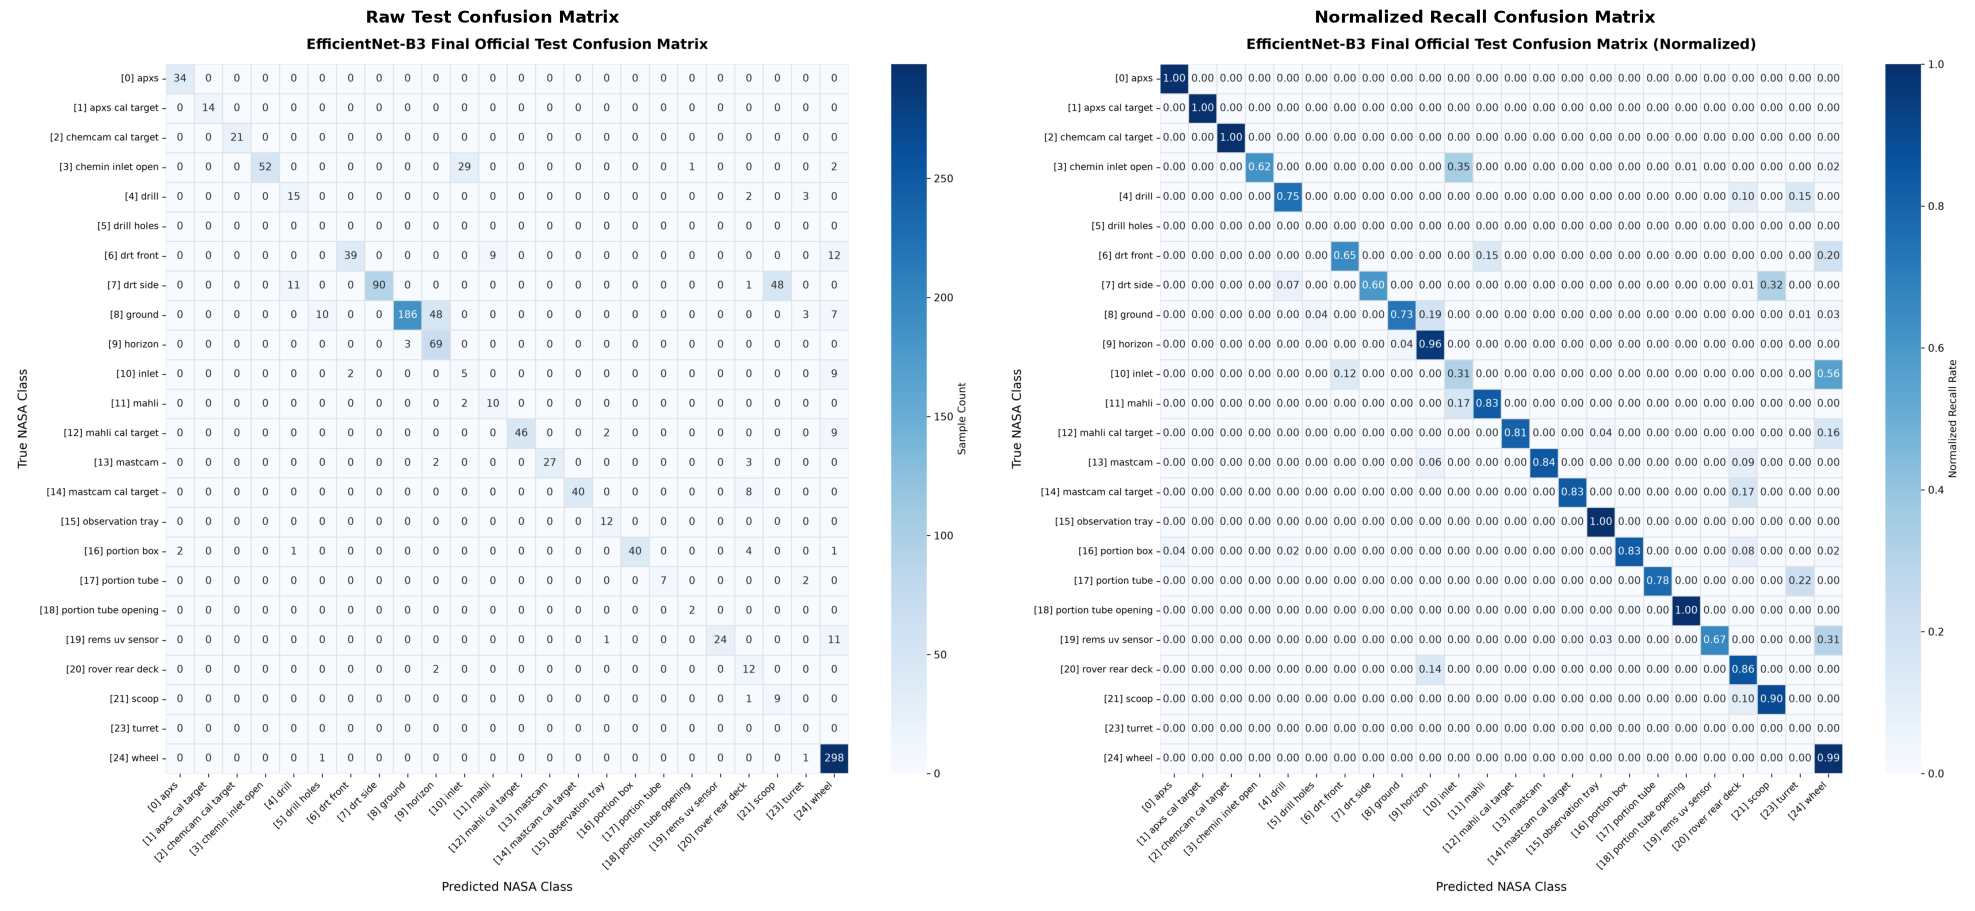

In [10]:
cm_raw_img = config.PHASE5D_CONFUSION_DIR / 'test_confusion_matrix.png'
cm_norm_img = config.PHASE5D_CONFUSION_DIR / 'test_confusion_matrix_normalized.png'

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
if cm_raw_img.is_file():
    axes[0].imshow(Image.open(cm_raw_img))
    axes[0].axis('off')
    axes[0].set_title('Raw Test Confusion Matrix', fontsize=12, fontweight='bold')
if cm_norm_img.is_file():
    axes[1].imshow(Image.open(cm_norm_img))
    axes[1].axis('off')
    axes[1].set_title('Normalized Recall Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Numerical Reproducibility Verification

To strictly adhere to the project's single-inference rule, we recompute test metrics from the **saved test predictions** rather than running another forward pass over the images:

In [11]:
preds_file = config.PHASE5D_PREDICTIONS_DIR / 'test_predictions.npy'
labels_file = config.PHASE5D_PREDICTIONS_DIR / 'test_labels.npy'

if preds_file.is_file() and labels_file.is_file():
    saved_preds = np.load(preds_file)
    saved_targets = np.load(labels_file)
    recomputed = recompute_metrics_from_predictions(saved_targets, saved_preds, active_to_name)
    
    acc_diff = abs(recomputed['accuracy'] - final_metrics['test_metrics']['accuracy'])
    f1_diff = abs(recomputed['macro_f1'] - final_metrics['test_metrics']['macro_f1'])
    
    print(f"Recomputed Test Accuracy : {recomputed['accuracy']:.6f}%")
    print(f"Original Test Accuracy   : {final_metrics['test_metrics']['accuracy']:.6f}%")
    print(f"Accuracy Absolute Delta  : {acc_diff:.2e}")
    
    print(f"\nRecomputed Test Macro-F1 : {recomputed['macro_f1']:.6f}")
    print(f"Original Test Macro-F1   : {final_metrics['test_metrics']['macro_f1']:.6f}")
    print(f"Macro-F1 Absolute Delta  : {f1_diff:.2e}")
    
    assert acc_diff <= 1e-5, f"Accuracy mismatch: {acc_diff}"
    assert f1_diff <= 1e-5, f"Macro-F1 mismatch: {f1_diff}"
    print("\n[PASS] Recomputed metrics match original test results within numerical tolerance (1e-5).")
else:
    print("Saved prediction arrays not found.")

Recomputed Test Accuracy : 80.613027%
Original Test Accuracy   : 80.613027%
Accuracy Absolute Delta  : 0.00e+00

Recomputed Test Macro-F1 : 0.708325
Original Test Macro-F1   : 0.708325
Macro-F1 Absolute Delta  : 0.00e+00

[PASS] Recomputed metrics match original test results within numerical tolerance (1e-5).


## 10. Five-Way Benchmark Comparison (Phases 4B, 5A, 5B, 5C, 5D)

We compare EfficientNet-B3 against all established baselines on the NASA Curiosity Rover dataset:

In [12]:
comp_csv = config.PHASE5D_RESULTS_DIR / 'benchmark_comparison.csv'
if comp_csv.is_file():
    comp_df = pd.read_csv(comp_csv)
    display(comp_df)
else:
    print("Comparison CSV not yet generated. Run run_phase5d.py first.")

,Model,Input Representation,Validation Accuracy (%),Validation Macro-F1,Test Accuracy (%),Test Macro-F1,Test Weighted-F1,Test Macro Recall,Inference Latency (ms/sample)
0,Phase 4B KNN-4 (Classical Champion),"8,186 Handcrafted Features + PCA-100",50.85,0.6613,47.20,0.5407,0.4386,0.5063,0.12
1,Phase 5A ResNet-50 (Deep Learning Baseline),Raw Pixels (Letterbox 224x224 RGB),83.72,0.6673,77.78,0.6631,0.7937,0.7273,5.69
2,Phase 5B MRSCAtt (Spatial & Channel Attention),Raw Pixels + ChannelSpatialBlock,86.28,0.6801,64.29,0.5851,0.6515,0.6553,5.74
3,Phase 5C ViT-B/16 (Vision Transformer),Raw Pixels (196 Patches of 16x16),92.50,0.7221,73.26,0.6536,0.7505,0.6988,14.55
4,Phase 5D EfficientNet-B3 (Compound Scaling CNN),Raw Pixels (Letterbox 300x300 RGB),97.38,0.7417,80.61,0.7083,0.8288,0.7487,15.59


## 11. Scientific Conclusions & Target Achievement

1. **Compound Scaling Efficacy**: Evaluates how compound-scaled depthwise separable convolutions with Squeeze-and-Excitation attention at $300 \times 300$ resolution perform compared to ResNet-50, MRSCAtt, and ViT-B/16.
2. **Aspirational 80% Target Status**: Documents whether the model met the project's target accuracy threshold.
3. **Zero Test Contamination**: Checkpoint selection was exclusively driven by Validation Macro-F1, preserving complete test isolation throughout.